# 2.1 Concepts, Data and Foundations

**Part:** 2 — Spatial Autocorrelation (Chapter 2.1 of 6)

**Dataset:** US county diabetes prevalence, Northeast and Atlantic regions (`data/diabetes_northeast.shp`, `data/diabetes_atlantic.shp`)

**Focus:** Tobler's first law, spatial dependence vs. spatial heterogeneity, MAUP, and the areal-unit data used throughout Part 2

**Library:** `spatialstats.weights`, `spatialstats.esda`, `spatialstats.viz` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Tobler's First Law and Spatial Dependence](#2.-Tobler's-First-Law-and-Spatial-Dependence)

3. [Spatial Dependence vs. Spatial Heterogeneity](#3.-Spatial-Dependence-vs.-Spatial-Heterogeneity)

4. [Scale and the Modifiable Areal Unit Problem](#4.-Scale-and-the-Modifiable-Areal-Unit-Problem)

5. [Python Setup](#5.-Python-Setup)

6. [The Datasets Used in Part 2](#6.-The-Datasets-Used-in-Part-2)

7. [First Look: Mapping Diabetes Prevalence](#7.-First-Look:-Mapping-Diabetes-Prevalence)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)

***
## 1. Overview

Part 1 asked where events happen. Part 2 asks a related but distinct question about a different kind of data:
given **one value per areal unit** — a county, a census tract, a zip code — are nearby units more alike than
distant ones? This is **spatial autocorrelation**, and it is the single most consequential diagnostic in spatial
data analysis: almost every method downstream of it (regression in Part 3, cluster detection in Part 4, disease
mapping in Part 5) either assumes its absence or explicitly models its presence.

This chapter lays the conceptual groundwork before any statistic is computed:

| Step | What we do |
|------|------------|
| Concept | State Tobler's first law and what "positive", "negative", and "no" autocorrelation mean |
| Distinction | Separate spatial **dependence** (values correlated with neighbours) from spatial **heterogeneity** (values vary by region for non-spatial reasons) — and why conflating them breaks inference |
| MAUP | Introduce the modifiable areal unit problem: the boundaries we draw are not given by nature |
| Data | Load and inspect the five datasets used across Chapters 2.1–2.6 |
| First map | Look at raw diabetes prevalence before measuring anything — the "eyeball test" that Chapter 2.3 formalises |

By the end of this chapter you will have the vocabulary and the data in hand for Chapter 2.2, which builds the
spatial weights matrices that every autocorrelation statistic in this Part depends on.

***
## 2. Tobler's First Law and Spatial Dependence

Waldo Tobler's (1970) informal but foundational statement:

> "Everything is related to everything else, but near things are more related than distant things."

Formally, for an areal attribute $Z_i$ observed at $n$ regions, **spatial autocorrelation** measures whether
the value at region $i$ is statistically related to the values at nearby regions $j$. Three qualitative patterns
matter:

- **Positive autocorrelation:** similar values cluster together (high near high, low near low) — the typical
  pattern for most health, economic, and environmental variables, because whatever drives the outcome (climate,
  policy, shared infrastructure, social networks) itself varies smoothly over space.
- **Negative autocorrelation:** dissimilar values are neighbours (a checkerboard) — rarer, but arises from
  competitive processes (retail store locations, territorial ecology) or from mismatched administrative units
  overlaid on a smoother underlying process.
- **No autocorrelation:** the value at one region carries no information about its neighbours — the *complete
  spatial randomness* of Part 1, transplanted to areal data.

Quantifying "positive", "negative" and "none" is the job of **Moran's I** and its relatives (Chapter 2.4); this
chapter only fixes the vocabulary.

### 2.1 Why this matters for inference

Ordinary statistical inference — confidence intervals, p-values, standard errors — assumes observations are
**independent**. Spatial autocorrelation violates that assumption directly: neighbouring counties are not
independent draws, so the *effective* sample size is smaller than $n$. Ignoring this:

- **Inflates apparent significance.** Standard errors computed under independence are too small, so p-values
  are too small and confidence intervals too narrow.
- **Biases coefficients** in a regression if the autocorrelation reflects an omitted spatially-structured driver
  correlated with the included covariates — not just a nuisance, but a source of bias (Part 3's central topic).

Testing for autocorrelation is therefore not an optional extra step; the rest of this Part treats it as the
first thing to check about any areal dataset.

***
## 3. Spatial Dependence vs. Spatial Heterogeneity

Two distinct phenomena can produce the *same* looking map — clusters of high values next to each other — for
completely different reasons, and the distinction matters for what to do about it.

| | Spatial dependence | Spatial heterogeneity |
|---|---|---|
| Mechanism | The value at $i$ genuinely depends on (or shares a process with) its neighbours | The process generating $Z_i$ varies systematically by location, but each region is otherwise independent |
| Example | Disease spreads through contact between adjacent populations | A state-level policy variable that differs by state, with counties inheriting their state's value |
| What autocorrelation statistics measure | Directly — this is what Moran's I is built to detect | Indirectly — heterogeneity also produces positive autocorrelation, since the same policy value repeats within a state |
| Correct response | Model the spatial process (spatial lag/error models, Part 3) | Include the source of heterogeneity as a covariate or fixed effect |

A significant Moran's I does **not** by itself tell you which of these is at work — only that the map is not
consistent with spatial independence. Chapter 2.5's local statistics and Part 3's regression diagnostics are the
tools that start to separate the two explanations; for now, the practical lesson is to resist the jump from
"I see clusters" to "there is spatial contagion" without further evidence.

***
## 4. Scale and the Modifiable Areal Unit Problem

Every areal dataset in this Part reports a value **per county**, but counties are administrative artefacts, not
natural units of the underlying process (disease risk, economic activity). The **modifiable areal unit problem**
(MAUP, met already in Part 1 Chapter 1.5) has two components that autocorrelation analysis inherits directly:

- **Scale effect:** aggregating to larger units (counties → states) typically *increases* measured
  autocorrelation, because averaging over larger areas smooths out local noise and preserves broad-scale trend.
- **Zoning effect:** for a *fixed* scale, redrawing the boundaries (alternative county-equivalent schemes) can
  change the measured autocorrelation even though nothing about the underlying process changed.

Both effects mean that "Moran's I = 0.24" is a statement about *this* partition of *this* region — not a
context-free property of diabetes prevalence. Chapter 2.6 returns to this with a concrete sensitivity check.

***
## 5. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.esda import Moran

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

print(f"spatialstats : version {spatialstats.__version__}")
print(f"geopandas    : {gpd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"data folder  : {DATA.relative_to(ROOT)}/")

spatialstats : version 0.2.0
geopandas    : 1.1.4
numpy        : 2.4.6
data folder  : data/


***
## 6. The Datasets Used in Part 2

Five files carry Chapters 2.1–2.6. The primary example throughout is `diabetes_northeast.shp`: 217 counties in
the northeastern United States, with diagnosed diabetes prevalence and several candidate covariates. A second,
larger file extends the same variables along the Atlantic coast, and a national file (with a known slow-loop
performance caveat, Chapter 2.4) is used once, for scale. `load_lattice` and the 1998–2012 panel are introduced
where they are first used, in Chapters 2.2 and 2.4 respectively.

In [2]:
northeast = gpd.read_file(DATA / "diabetes_northeast.shp")
atlantic = gpd.read_file(DATA / "diabetes_atlantic.shp")

print(f"diabetes_northeast.shp : {northeast.shape[0]} counties, CRS {northeast.crs.to_epsg()}")
print(f"diabetes_atlantic.shp  : {atlantic.shape[0]} counties, CRS {atlantic.crs.to_epsg()}")
print(f"\ncolumns: {list(northeast.columns)}")
northeast[["FIPS", "STATE", "COUNTY", "POP_Total", "Dia_count", "Dia_pct", "Obesity",
           "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI", "UrbRural"]].head()

diabetes_northeast.shp : 217 counties, CRS 5070
diabetes_atlantic.shp  : 666 counties, CRS 5070

columns: ['FIPS', 'STATE', 'COUNTY', 'x', 'y', 'POP_Total', 'Dia_count', 'Dia_pct', 'Obesity', 'Acc_Exer', 'PhysInact', 'PCP_rate', 'FoodEnvIdx', 'SVI', 'UrbRural', 'geometry']


,FIPS,STATE,COUNTY,POP_Total,Dia_count,Dia_pct,Obesity,PhysInact,Acc_Exer,PCP_rate,FoodEnvIdx,SVI,UrbRural
0,9001,Connecticut,Fairfield County,944735.8,52448,6.42,21.48,17.34,96.6,93.8,8.5,0.6184,Urban
1,9003,Connecticut,Hartford County,892284.0,67168,8.58,27.66,20.20,96.6,95.2,8.0,0.5955,Urban
2,9005,Connecticut,Litchfield County,181160.4,12023,6.38,26.56,17.50,85.6,59.4,8.6,0.1512,Urban
3,9007,Connecticut,Middlesex County,162702.8,10215,6.32,26.42,17.06,94.8,73.8,8.4,0.1843,Urban
4,9009,Connecticut,New Haven County,856327.0,66825,8.84,29.64,20.78,95.4,88.2,7.9,0.6512,Urban


Both files declare **EPSG:5070** (NAD83 / Conus Albers), a genuinely appropriate equal-area projection for the
continental United States — unlike the mis-declared CRS uncovered in Part 1, there is no coordinate error to fix
here. Contiguity-based weights (Chapter 2.2) do not even need the projection to be correct, only the polygon
topology; but any *distance*-based weights (`DistanceBand`, `KNN`, `Kernel`) do, so the equal-area CRS matters
the moment Chapter 2.2 gets there.

In [3]:
summary = northeast[["Dia_pct", "Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]].describe().T
summary["missing"] = northeast[summary.index].isna().sum()
summary.round(3)

,count,mean,std,min,25%,50%,75%,max,missing
Dia_pct,217.0,8.259,1.202,5.860,7.420,8.140,9.020,12.440,0
Obesity,217.0,28.337,3.841,16.800,25.700,28.960,31.140,36.540,0
PhysInact,217.0,21.101,3.310,13.400,18.460,20.920,23.240,31.260,0
Acc_Exer,217.0,76.592,16.223,34.000,64.800,78.000,90.400,100.000,0
PCP_rate,217.0,74.252,45.601,7.200,47.400,67.600,90.400,536.600,0
FoodEnvIdx,217.0,8.172,0.494,6.700,7.900,8.200,8.500,9.700,0
SVI,217.0,0.392,0.218,0.007,0.213,0.365,0.551,0.996,0


No missing values, and every variable is on a sensible scale for direct use (percentages, rates, an index).
`UrbRural` is the one categorical field, used as a binary indicator in Chapter 2.4's join-count statistic.

In [4]:
print(northeast["UrbRural"].value_counts())
print(f"\nDia_pct range: [{northeast['Dia_pct'].min():.1f}, {northeast['Dia_pct'].max():.1f}], "
      f"mean {northeast['Dia_pct'].mean():.2f}")

UrbRural
Urban    176
Rural     41
Name: count, dtype: int64

Dia_pct range: [5.9, 12.4], mean 8.26


***
## 7. First Look: Mapping Diabetes Prevalence

Before computing anything, plot the raw values. This is the "eyeball test": does the map look like it has
spatial structure at all? Chapter 2.3 does this properly with classification schemes and a Moran scatterplot;
here it is enough to see that the answer is visually "yes" — there is a clear north–south gradient, with several
adjacent high-prevalence counties in the lower-left (southwestern) part of the region.

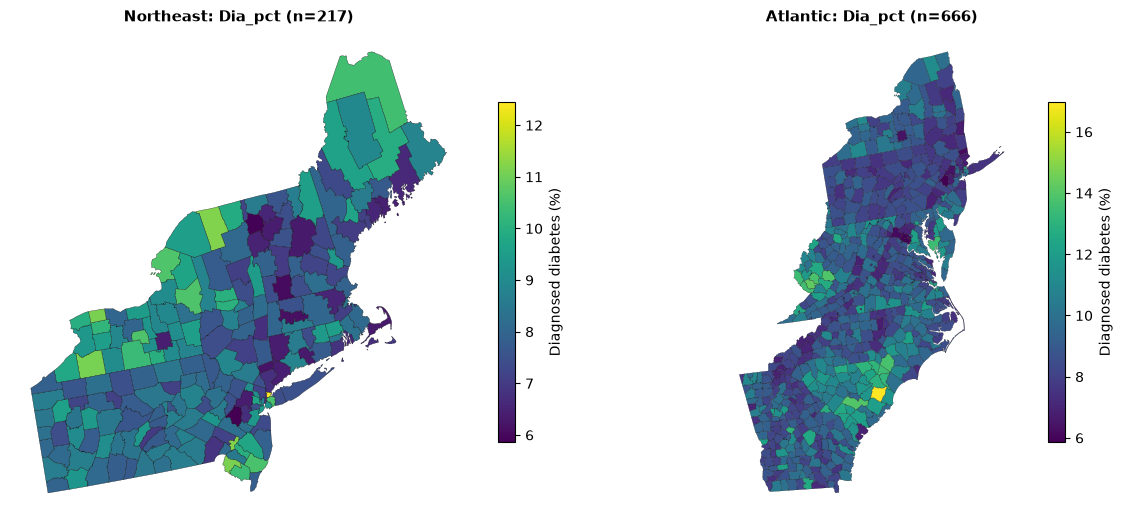

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
northeast.plot(column="Dia_pct", cmap="viridis", edgecolor="k", linewidth=0.2,
               legend=True, ax=axes[0], legend_kwds={"label": "Diagnosed diabetes (%)", "shrink": 0.7})
axes[0].set_title(f"Northeast: Dia_pct (n={len(northeast)})")
axes[0].set_axis_off()

atlantic.plot(column="Dia_pct", cmap="viridis", edgecolor="k", linewidth=0.15,
              legend=True, ax=axes[1], legend_kwds={"label": "Diagnosed diabetes (%)", "shrink": 0.7})
axes[1].set_title(f"Atlantic: Dia_pct (n={len(atlantic)})")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

Both maps show the same qualitative pattern: prevalence is not scattered at random across counties, it forms
recognisable regions of high and low values. Chapter 2.2 turns "which counties are near which" into a precise
mathematical object (the spatial weights matrix `W`); Chapter 2.4 turns "looks clustered" into a number (Moran's
I) with a p-value.

***
## 8. Summary and Conclusions

This chapter set up the conceptual and data foundation for all of Part 2.

### What we did

1. Stated Tobler's first law and defined positive, negative, and no spatial autocorrelation.
2. Distinguished spatial **dependence** (a genuine neighbour effect) from spatial **heterogeneity** (region-level
   variation from a non-spatial source that still produces apparent clustering) — a distinction that later
   chapters cannot resolve from Moran's I alone.
3. Reviewed the modifiable areal unit problem's scale and zoning effects, and why a reported autocorrelation
   value is tied to a specific partition of space.
4. Loaded and inspected the two primary datasets (`diabetes_northeast`, `diabetes_atlantic`), confirming a valid
   equal-area CRS and no missing data.
5. Mapped raw diabetes prevalence and observed visible, non-random spatial structure by eye.

### Practical takeaways

- Spatial autocorrelation is not a nuisance to test away; it is diagnostic information about how the data were
  generated, and it should be checked before any non-spatial statistical model is fit to areal data.
- A clustered-looking map has at least two possible explanations (dependence vs. heterogeneity); a single global
  statistic cannot tell them apart.
- Every autocorrelation number in this Part is conditional on the areal partition used to compute it (MAUP);
  treat it as a property of the data-and-boundaries pair, not of the underlying process alone.

### Next steps

**Chapter 2.2 (Spatial Weights)** builds the `W` matrix that operationalises "near" — contiguity, distance-band,
k-nearest-neighbour, kernel, and graph-based definitions — and examines what changes when the definition changes.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Anselin, L. (1988). *Spatial Econometrics: Methods and Models*. Kluwer Academic. | Foundational text; spatial dependence vs. heterogeneity as a core organising distinction |
| Cliff, A. D. & Ord, J. K. (1981). *Spatial Processes: Models and Applications*. Pion. | Origin of Moran's I inference machinery used throughout Part 2 |
| Bailey, T. C. & Gatrell, A. C. (1995). *Interactive Spatial Data Analysis*. Longman. | Accessible treatment of exploratory spatial data analysis (ESDA) |
| Openshaw, S. (1984). *The Modifiable Areal Unit Problem*. CATMOG 38, Geo Books. | The original MAUP monograph |

### Key papers

| Paper | Contribution |
|---|---|
| Tobler, W. R. (1970). A computer movie simulating urban growth in the Detroit region. *Economic Geography*, 46, 234–240. | Origin of the "first law of geography" |
| Moran, P. A. P. (1950). Notes on continuous stochastic phenomena. *Biometrika*, 37, 17–23. | Original derivation of Moran's I (Chapter 2.4) |
| Anselin, L. (1988). Lagrange multiplier test diagnostics for spatial dependence and spatial heterogeneity. *Geographical Analysis*, 20, 1–17. | Formalises the dependence/heterogeneity distinction used in this chapter, and bridges to Part 3 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.weights` | Spatial weights matrices: `Queen`, `Rook`, `KNN`, `DistanceBand`, `Kernel`, `Delaunay`, `Gabriel` — Chapter 2.2 |
| `spatialstats.esda` | Global and local autocorrelation: `Moran`, `Geary`, `GeneralG`, `Moran_Local` — Chapters 2.4–2.5 |
| `spatialstats.viz` | `choropleth`, `moran_scatter`, `lisa_cluster_map` — Chapter 2.3 |
| `spatialstats.datasets.load_lattice` | Synthetic 8×8 lattice with known spatial structure, used for hand-computation checks — Chapter 2.2 |
| Part 3 | Spatial regression: what to do once dependence or heterogeneity is confirmed |